Initial Spam Classifier using LSTM and BCEwithLogitLoss
Author: Rolando Reategui Arones
Date: 25.05.2026

In [28]:
from datasets import load_dataset
print("datasets import works")
import torch 

import torch.nn as nn
import torch.optim as optim
import nltk
import regex as re
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from nltk.corpus import stopwords
from torch.utils.data import DataLoader, Dataset
from collections import Counter

datasets import works


In [29]:
# reproducibility seed

import random
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [30]:
splits = {'train': 'data/train-00000-of-00001-daf190ce720b3dbb.parquet', 'test': 'data/test-00000-of-00001-fa9b3e8ade89a333.parquet'}

df_train = pd.read_parquet("hf://datasets/Deysi/spam-detection-dataset/" + splits["train"])

df_test = pd.read_parquet("hf://datasets/Deysi/spam-detection-dataset/" + splits["test"])

df_train.head(10)

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam
5,Bridging the gap between artificial intelligen...,not_spam
6,hi all any good leads on datasets for fuel pri...,not_spam
7,"\n\nHi everyone,\n\nFor my thesis I'm looking...",not_spam
8,I'm looking for a large dataset of n-grams (pr...,not_spam
9,Check out these amazing weight loss pills! The...,spam


In [31]:
#Data cleaning
#stopwords: eliminate words that do not provide semantical meaning
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
def clean_data(text):#lowercase all words, remove stopwords ans alphanumeric characters

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    words = [w for w in text.split() if w not in stop_words]

    return " ".join(words)

#apply the cleaning to the text column and store the result in the clean_text column
df_train['clean_text'] = df_train['text'].apply(clean_data)

df_test['clean_text'] = df_test['text'].apply(clean_data)
#Spam->1 Not Spam->0
df_train["label"] = df_train["label"].map({"spam": 1, "not_spam": 0}).astype("float32")

df_test["label"] = df_test["label"].map({"spam": 1, "not_spam": 0}).astype("float32")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reate\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
df_train.head(10)

,text,label,clean_text
0,hey I am looking for Xray baggage datasets can...,0.0,hey looking xray baggage datasets provide
1,"""Get rich quick! Make millions in just days wi...",1.0,get rich quick make millions days new revoluti...
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,1.0,urgent message wont believe offer hey yeah eye...
3,[Google AI Blog: Contributing Data to Deepfake...,0.0,google ai blog contributing data deepfake dete...
4,Trying to see if anyone already has timestamps...,0.0,trying see anyone already timestamps key event...
5,Bridging the gap between artificial intelligen...,0.0,bridging gap artificial intelligence business ...
6,hi all any good leads on datasets for fuel pri...,0.0,hi good leads datasets fuel prices ad fuel con...
7,"\n\nHi everyone,\n\nFor my thesis I'm looking...",0.0,hi everyone thesis im looking daily count subs...
8,I'm looking for a large dataset of n-grams (pr...,0.0,im looking large dataset ngrams preferably 4gr...
9,Check out these amazing weight loss pills! The...,1.0,check amazing weight loss pills guaranteed she...


In [33]:
#Tokenization and vocabulary

#<PAD>  (padding token): Used to truncate sequences to a uniform length, 
# ensuring that all input sequences have the same length, which is necessary for batch processing.
#<UNK>  (unknown token): Used to represent out-of-vocabulary (OOV) words, 
# that is, words that are not in the training dataset, allowing the model 
# to handle unseen words during inference.
def tokenize(text):
    return text.split()

train_texts = df_train["clean_text"]

all_tokens = [token for text in train_texts for token in tokenize(text)]

vocab = {word: i+2 for i, word in enumerate(Counter(all_tokens))} # has all the words from the whole dataset start from 2

vocab["<PAD>"] = 0

vocab["<UNK>"] = 1
print(vocab)

{'hey': 2, 'looking': 3, 'xray': 4, 'baggage': 5, 'datasets': 6, 'provide': 7, 'get': 8, 'rich': 9, 'quick': 10, 'make': 11, 'millions': 12, 'days': 13, 'new': 14, 'revolutionary': 15, 'system': 16, 'dont': 17, 'miss': 18, 'amazing': 19, 'opportunity': 20, 'urgent': 21, 'message': 22, 'wont': 23, 'believe': 24, 'offer': 25, 'yeah': 26, 'eyes': 27, 'reading': 28, 'right': 29, 'want': 30, 'coolest': 31, 'cat': 32, 'block': 33, 'likes': 34, 'hearts': 35, 'emojis': 36, 'popular': 37, 'well': 38, 'solution': 39, 'introducing': 40, 'brand': 41, 'feature': 42, 'blow': 43, 'mind': 44, 'feed': 45, 'cant': 46, 'give': 47, 'away': 48, 'many': 49, 'details': 50, 'lets': 51, 'say': 52, 'involves': 53, 'puppies': 54, 'unicorns': 55, 'drum': 56, 'kit': 57, 'wait': 58, 'theres': 59, 'sign': 60, 'google': 61, 'ai': 62, 'blog': 63, 'contributing': 64, 'data': 65, 'deepfake': 66, 'detection': 67, 'researchhttpsaigoogleblogcom201909contributingdatatodeepfakedetectionhtml': 68, 'gttoday': 69, 'september': 

Next up is the encoder function, which tokenizes the input  text  into individual tokens and converts them into corresponding IDs by using the  vocab  dictionary. If the length of the IDs is less than the specified  max_len  of 50, the function pads the IDs with zeros to reach the maximum length. The function then returns the encoded IDs, truncated to  max_len  if necessary.

In [34]:
def encode(text, max_len=50):#will have length 50 

        tokens = tokenize(text)

        ids = [vocab.get(t, 1) for t in tokens]

        if len(ids) < max_len:

                ids += [0] * (max_len - len(ids))

        else:

                ids = ids[:max_len]

        return ids

SpamDataset class

In [35]:
class SpamDataset(Dataset):

    def __init__(self, texts, labels):
        self.texts = [torch.tensor(encode(t), dtype=torch.long) for t in texts] #converts the texts into tensors with id of each token
        self.labels = torch.tensor(labels, dtype=torch.float32) #one tensor for all the labels

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, index):
        return self.texts[index], self.labels[index]

Define instances

In [36]:
train_texts = df_train['clean_text']
train_labels = df_train['label'].to_numpy(copy=True)
print("Train texts")
print(train_texts)
test_texts = df_test['clean_text']
test_labels = df_test['label'].to_numpy(copy=True)

train_ds = SpamDataset(train_texts, train_labels)
test_ds = SpamDataset(test_texts, test_labels)
print("train_ds",train_ds.texts)
print("labels",train_ds.labels)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=True)

Train texts
0               hey looking xray baggage datasets provide
1       get rich quick make millions days new revoluti...
2       urgent message wont believe offer hey yeah eye...
3       google ai blog contributing data deepfake dete...
4       trying see anyone already timestamps key event...
                              ...                        
8170    hi create datasets taking pictures specific ob...
8171    deals deals deals hey peeps wont believe amazi...
8172    hi working project need penalty conceding scor...
8173    want blow social media followers instantly loo...
8174    wazzup fellow netizens time get scrollin finge...
Name: clean_text, Length: 8175, dtype: str
train_ds [tensor([2, 3, 4, 5, 6, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0]), tensor([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  

Defining the model: embed layer + LSTM + Linear layer + sigmoid activation

In [37]:
class SpamClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)#embed_dim = size of each embedding vector
        self.lstm = nn.LSTM(input_size = embed_dim, hidden_size = hidden_dim, batch_first = True)
        self.fc = nn.Linear(in_features = hidden_dim, out_features = 1)
        
    def forward(self, x):
        x = self.embedding(x) # Embedding of x
        _, (hidden, _) = self.lstm(x)#1st output: (N,L,D*Hout), 2nd output: (hidden, cell) hidden:(D*num_layers,N,Hout), cell:(D*num_layers,N,Hcell)
        out = self.fc(hidden[-1])
        return out.squeeze(1)

In [38]:
#instance Spam classifier
print(len(vocab))
model = SpamClassifier(vocab_size = len(vocab))
print(model)

#Training
device = torch.device("cpu")
print(device)
model.to(device)
criterion = nn.BCEWithLogitsLoss()
optim = torch.optim.Adam(model.parameters(),lr = 0.001)

epochs = 5

train_losses = []

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for X, y in train_dl:#X: tensor of text tokens, y: tensor of labels

        X, y = X.to(device), y.to(device)

        optim.zero_grad()

        logits = model(X)#output of model is prob

        loss = criterion(logits, y)#compute loss


        loss.backward()

        optim.step()

        train_loss += loss.item()

    train_losses.append(train_loss/len(train_dl))

    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_dl):.4f}")

22754
SpamClassifier(
  (embedding): Embedding(22754, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
cpu
Epoch 1 | Loss: 0.4677
Epoch 2 | Loss: 0.3706
Epoch 3 | Loss: 0.3058
Epoch 4 | Loss: 0.2027
Epoch 5 | Loss: 0.1240


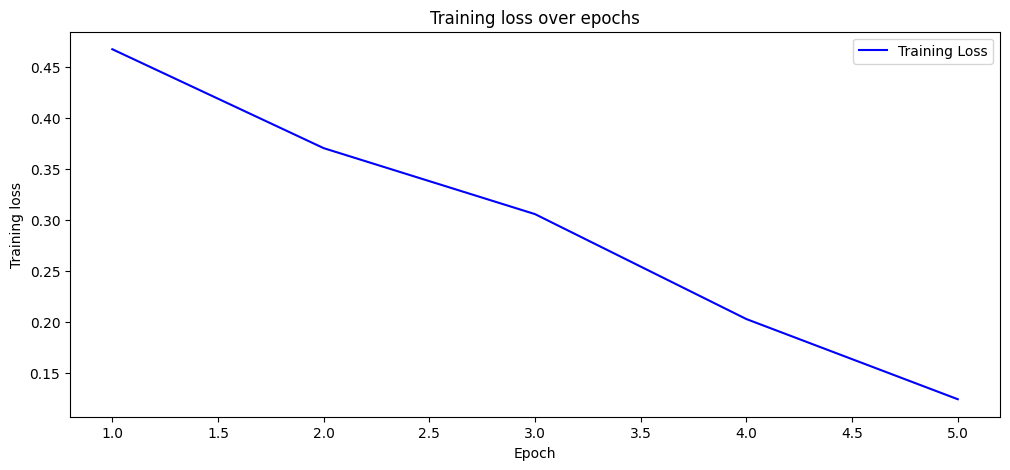

In [39]:
epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.plot(epochs, train_losses, label='Training Loss', color='blue')

plt.title('Training loss over epochs')

plt.xlabel('Epoch')

plt.ylabel('Training loss')

plt.legend()

plt.show()

In [40]:
#Evaluation
model.eval()

correct, total = 0, 0

with torch.no_grad():

    for X, y in test_dl:

        X, y = X.to(device), y.to(device)

        preds = model(X)

        preds_cls = (preds > 0.5).float()
        print(preds,y)

        correct += (preds_cls == y).sum().item()

        total += y.size(0)

print(f"Final accuracy: {correct / total:.4f}")


tensor([-2.3571, -2.5475, -3.2878, -3.2872,  4.5587,  4.5590, -3.2434, -3.2872,
        -3.2883,  4.5569,  4.5585, -3.2883,  4.5571, -3.2820, -3.1233,  4.4852,
         4.2794, -3.2879,  4.5590, -3.0903,  4.2369, -2.8839, -3.2826,  4.5591,
        -3.2878,  4.5591,  4.6134,  4.5573,  4.5527, -3.2816,  4.5591, -3.2884]) tensor([0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0.,
        1., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0.])
tensor([ 4.3747,  4.5575, -3.2872,  4.5589,  4.2849, -3.2863, -3.2883,  4.5590,
         4.5589,  4.3895,  4.0213,  4.5567, -3.2882,  4.1251,  4.5590, -3.2522,
         4.5591,  3.8818, -2.9373,  4.5587, -3.2874, -3.2881, -2.1678, -3.2853,
        -2.3077, -2.4947, -3.2777, -2.8110,  3.6592, -3.2876, -2.0844, -3.2839]) tensor([1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1.,
        0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.])
tensor([-3.2777, -0.4367, -3.2885,  4.5590,  4.5591,  4.1365,  4.559